## Prerequisites!
This script, to be well executed, assumes that you have downloaded and unzipped the dataset.zip folder of the experiment data found here: https://zenodo.org/uploads/18745702 (contains annotation.json + an "images" folder), on the same level as ''input'' and ''scripts''
- Dataset is a set of cropped text lines in .png format, as well as an annotation.json containing the transcription label of the images, as well as metadata such as the folio the line belongs to, etc. 
- ''input'' contains the data computed from the dataset using the DTLR for paleography architecture, aka: a folder per page with its extracted prototypes/a character_measurement folder with a .json per line with the metrics on bounding boxes per character.

![diagram](./media/explanation_dataset_components.png)

# Imports

In [1]:
import os
import re
import json
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict

from PIL import Image
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib import colors, cm

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.lines import Line2D

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

plt.rcParams['text.usetex'] = True

import sys
sys.path.append(str(Path("scripts")))

from metrics_viz import (StudyConfig, FolioIndex, compute_letter_metrics, compute_bigram_metrics, 
                                 compute_word_metrics, plot_linear, plot_cross)
from build_corpus import (build_doc_mappings, build_line_mappings, build_character_index_map, 
                        build_and_crop_working_corpus, compute_working_corpus_statistics)

# File Paths

In [2]:
from pathlib import Path

# start from current working directory
current = Path().resolve()

# walk upward until we find a marker of the repo root
for parent in [current] + list(current.parents):
    if (parent / "input").exists() and (parent / "dataset").exists():
        base_dir = parent
        break
else:
    raise FileNotFoundError("Could not locate project root (input/ and dataset/ missing)")

In [3]:
# --- Subpaths ---
#inputs
prototypes                  = base_dir / "input/prototypes"
character_mapping           = base_dir / "input/transcribe.json"
character_measurements      = base_dir / "input/character_measurements"

#dataset
annotation_json             = base_dir / "dataset/annotation.json"
text_line_images            = base_dir / "dataset/images"

#save results
fig_output_dir              = base_dir / "results/figures"
cropped_character_bboxes    = base_dir / "results/cropped_character_bboxes"

# Define constants config for visualisations. Here we define filters, character and bigram markers, highlighting folios etc that we use for the analysis. If you use it on your own data...

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Define config constants (to reuse everywhere)
# ─────────────────────────────────────────────────────────────────────────────
config = StudyConfig(
    annotation_json = annotation_json,
    character_measurements     = character_measurements,
    fig_output_dir   = fig_output_dir,
    prototypes = prototypes,

    # ── Gathering ranges shown in every linear plot, chnge only if needed ─────────────────────────
    highlight_ranges = [
        ('1r',   '7v'),
        ('170r', '178r'), ('178r', '185v'),
        ('401r', '409r'), ('409r', '416v'),
        ('467r', '474v'), ('474v', '480v'),
    ],
    gathering_labels = {
        ('1r',   '7v'):   "Gath. I",
        ('170r', '178r'): "Gath. XXII",
        ('178r', '185v'): "Gath. XXIII",
        ('401r', '409r'): "Gath. LII",
        ('409r', '416v'): "Gath. LIII",
        ('467r', '474v'): "Gath. LXII",
        ('474v', '480v'): "Gath. LXIII",
    },
    
    # markers have sensible defaults, override only if needed:
    letter_markers   = {'a': 's', 't': 'x', 'd': '*', 'e': 'P', 'n': 'o'},
    bigram_markers   = {'en': 'o', 'de': 'p', 'le': '^'},

    # ── Filtering ────────────────────────────────────────────────────────────
    line_selection_mode    = "recto_verso",
    bbox_filter_mode       = "threshold",
    outlier_std_threshold  = 4.0,
)

idx = FolioIndex(config)
print(f"Corpus has {len(idx.all_folios_sorted)} total folios/pages")

Corpus has 164 total folios/pages


# Build dataset metadata  mappings (map characters to their image index, Graphic Profiles per page, lines to zone number (left or right column))

In [5]:
# ── Mappings (built once, reused everywhere) ──────────────────────────────
character_sprite_map = build_character_index_map(character_mapping)
doc_mappings,  _     = build_doc_mappings(annotation_json)
line_mappings, _     = build_line_mappings(annotation_json)

## We build our analysis corpus  from the available character bounding boxes, according to filtering strategy and compute statistics. This operation corresponds to the filtering of the bboxes described in "Discarding errors" of section 3.2. 

## More in detail:
- We first filter out the inner column lines, using "recto_verso" filtering mode. If you don't want to filter any Zone, delete "zone_mode"
- We also filter our any non 'DefaultLine' tagged line. Again, if you don't want to filter according to this logic, delete "line_mode"
- We set a standard deviation limit of "4" for discarding bboxes.
- When crop_images = True, bbox crops are produced separately for kept and discarded instances according to the criteria used.

In [9]:
corpus, stats, metadata_rows = build_and_crop_working_corpus(
    character_measurements=character_measurements,
    text_line_images=text_line_images,
    cropped_character_bboxes=cropped_character_bboxes,
    annotation_json=annotation_json,
    #zone_mode="recto_verso", # takes right column of recto and left of verso
    #line_mode="DefaultLine",
    #bbox_filter_mode="threshold",
    #outlier_std_threshold=4,
    target_characters=None, # so, all
    character_sprite_map=character_sprite_map,
    crop_images=False #True for cropped bboxes (kept, discarded)
)

df_gp, df_char = compute_working_corpus_statistics(corpus, stats)

Processing corpus: 100%|██████████████████| 6901/6901 [00:01<00:00, 5017.77it/s]



WORKING CORPUS — GP SUMMARY



,GP,Docs,Folios,DefaultLines,Total predictions,Match predictions,% discarded (no match),Final characters
0,GP1,66,66,5859,247456,244360,1.25,244360
1,GP2,54,54,4434,171271,168931,1.37,168931
2,GP3,38,38,2757,115339,113835,1.30,113835
3,GP4,6,6,535,22128,21821,1.39,21821



WORKING CORPUS — CHARACTER SUMMARY



,Character,Count
0,,94294
1,.,6370
2,:,41
3,A,142
4,B,109
...,...,...
72,Ꝙ,1
73,ꝙ,45
74,ꝯ,476
75,ꝰ,101


# From the available measurements provided by the bounding boxes of the corpus, we define metrics for computing the width, height, aspect ratio of a character as well as disatnce between characters and words (graphic units separated by a space). For the definitions of the computer metrics refer to the "compute_character_metrics" "compute_bigram_metrics" "compute_word_metrics" in metrics_viz.py. Metrics are computed per page (our unit of analysis).

## From all of the available measurements in the dataset, we create a df with the metrics for the letters/bigrams of interest as well as word separation

## See the dataframe and the  for the name per metric: *mean_ar_{character}* for example is the AR of "a" and *mean_b_distance_m_{bigram}* is the bigram distance normalized by half the average (per page) width of the lowercase m. On the definition of measures, see paper section 3.3 "Measures". 

![diagram](./media/measures_definition.jpeg)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  Compute metrics (Accumulate into one wide DataFrame)
#  Format is {metrics_name}_{selected_char or bigram}
# ─────────────────────────────────────────────────────────────────────────────
df = idx.base_df()

# letters
for char in ["n", "a", "t", "d", "e"]: 
    df = compute_letter_metrics(df, corpus, char, config)
# bigrams
for bigram in ["en", "de", "le"]:
    df = compute_bigram_metrics(df, bigram, config, idx)
# word
df = compute_word_metrics(df, config, idx)

# See which folios have no data at all
missing = df[df["mean_ar_n"].isna()]["folio"].tolist()
print(f"Pages with lines on the corpus with no data for the working corpus: {missing}")

# Confirm: from 164 pages, 160 rows have data for the selected units.
print(f"{df['mean_ar_n'].notna().sum()} units in the working corpus")
print(df.shape)
df.head()

Pages with lines on the corpus with no data for the working corpus: []
164 units in the working corpus
(164, 51)


,folder,folio,gp,mean_ar_n,std_ar_n,cv_ar_n,count_n,mean_ar_a,std_ar_a,cv_ar_a,...,mean_distance,std_distance,cv_distance,mean_w_distance_normalized_m,std_distance_normalized_m,cv_distance_normalized_m,mean_distance_normalized_avg,std_distance_normalized_avg,cv_distance_normalized_avg,n_word_distances
0,btv1b84472995_f009,1r,GP1,1.045296,0.050071,0.047901,174,0.997752,0.053793,0.053914,...,7.971703,5.613236,0.704145,0.272656,0.191989,0.704145,0.235881,0.166094,0.704145,312.0
1,btv1b84472995_f010,1v,GP1,1.067496,0.044567,0.041749,95,1.016031,0.044624,0.043920,...,10.212872,8.329806,0.815618,0.343840,0.280442,0.815618,0.295765,0.241231,0.815618,309.0
2,btv1b84472995_f011,2r,GP1,1.020306,0.042661,0.041812,11,0.994431,0.055375,0.055685,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,btv1b84472995_f015,4r,GP1,1.082705,0.037739,0.034856,20,1.047469,0.068154,0.065066,...,10.135592,5.476542,0.540328,0.326623,0.176483,0.540328,0.280484,0.151553,0.540328,30.0
4,btv1b84472995_f016,4v,GP1,1.042152,0.043598,0.041835,224,1.017298,0.053117,0.052214,...,9.689374,6.883575,0.710425,0.324995,0.230885,0.710425,0.282933,0.201003,0.710425,348.0


# Visualisations

![diagram](./media/dummy_graphs.jpeg)

See also the examples below.

## Linear plots. We plot the figures in the paper section 4.3, Figures 6 and 7. 

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:998: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: linear_mean_ar_a_mean_ar_n_mean_ar_t_mean_ar_d_mean_ar_e_recto_verso.jpeg


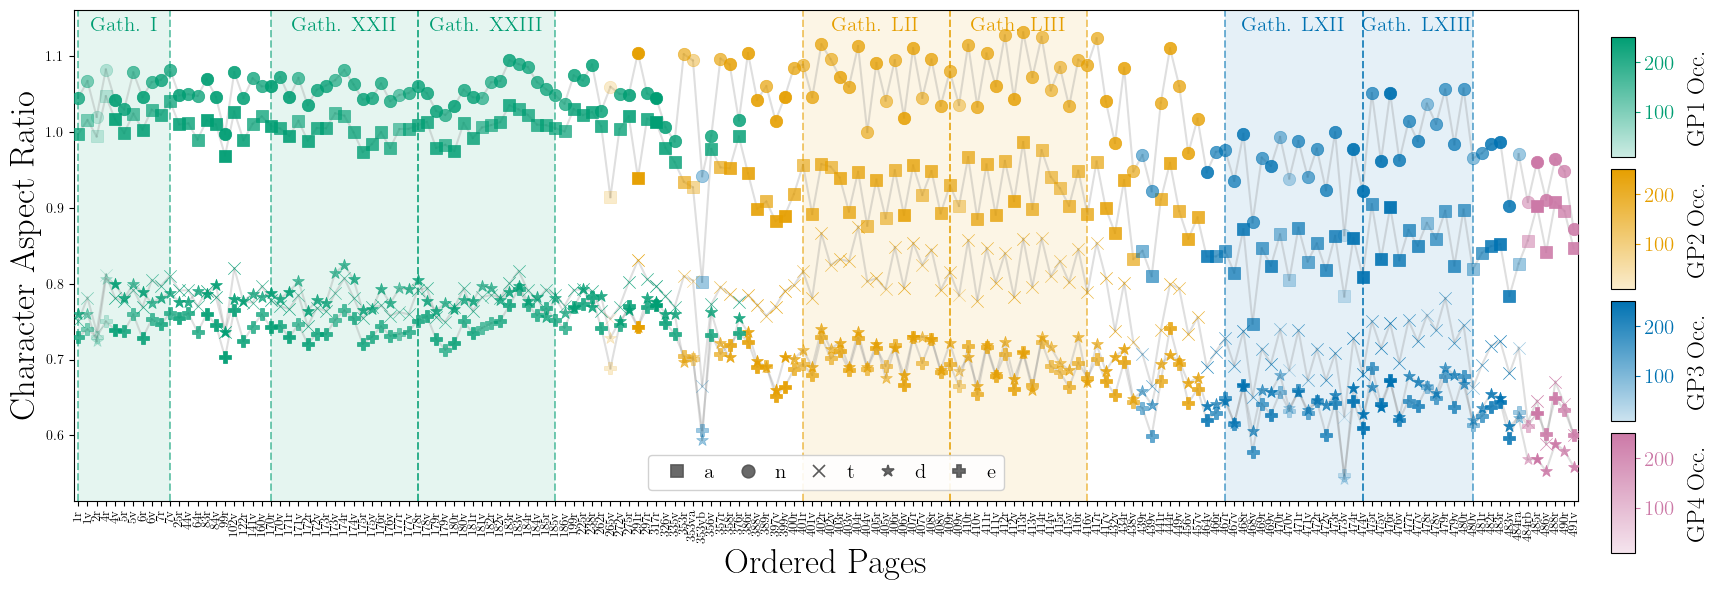

In [11]:
# ── LINEAR PLOTS ─────────────────────────────────────────────────────────────

# Letter AR: a, n, t, e, d
plot_linear(df, y_metric=["mean_ar_a", "mean_ar_n", "mean_ar_t", "mean_ar_d", "mean_ar_e"],
            config=config, idx=idx,
            y_label_override="Character Aspect Ratio")

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:998: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: linear_mean_b_distance_m_en_mean_b_distance_m_de_mean_b_distance_m_le_recto_verso.jpeg


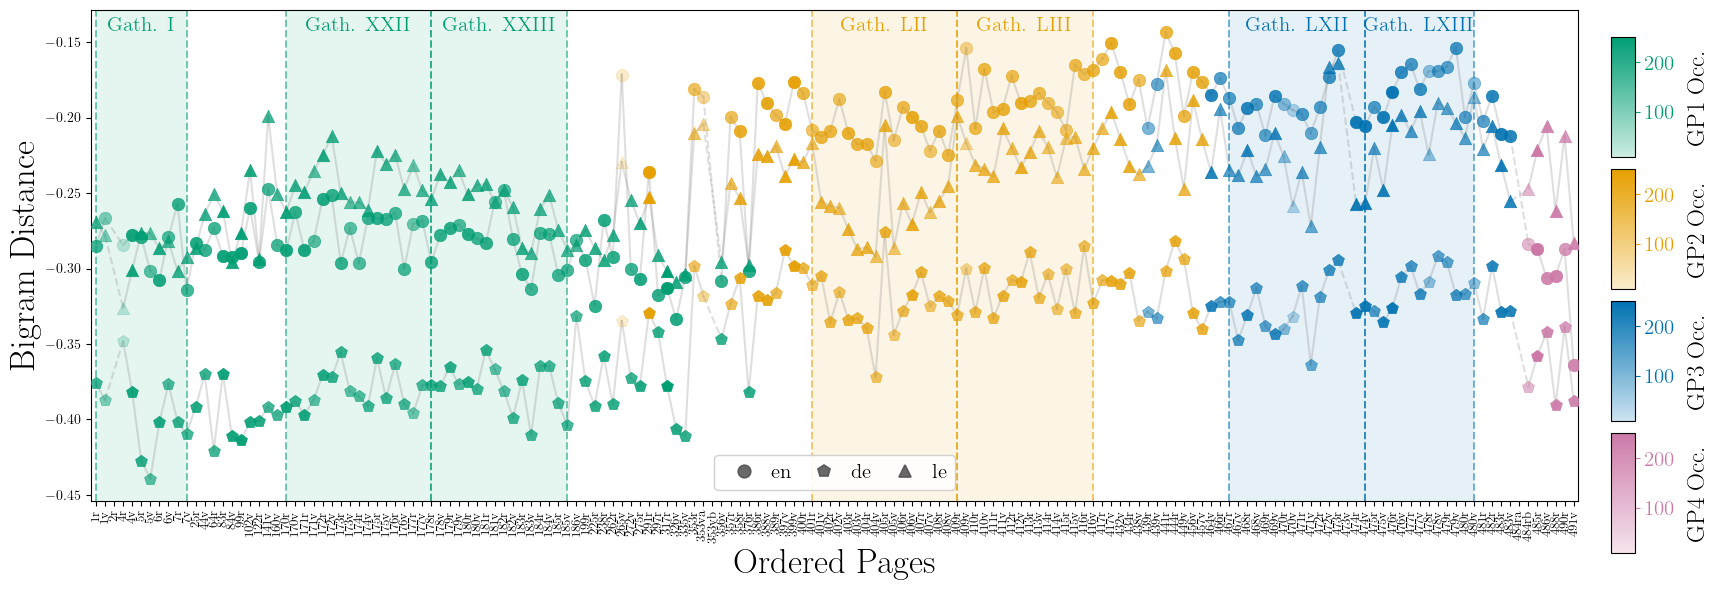

In [12]:
# Bigram edge-to-edge distance: en, de, le
plot_linear(df, y_metric=["mean_b_distance_m_en", "mean_b_distance_m_de", "mean_b_distance_m_le"],
            config=config, idx=idx,y_label_override="Bigram Distance")


/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/notebooks/metrological_analyses/metrics_viz.py:998: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: linear_mean_w_distance_normalized_m_recto_verso.jpeg


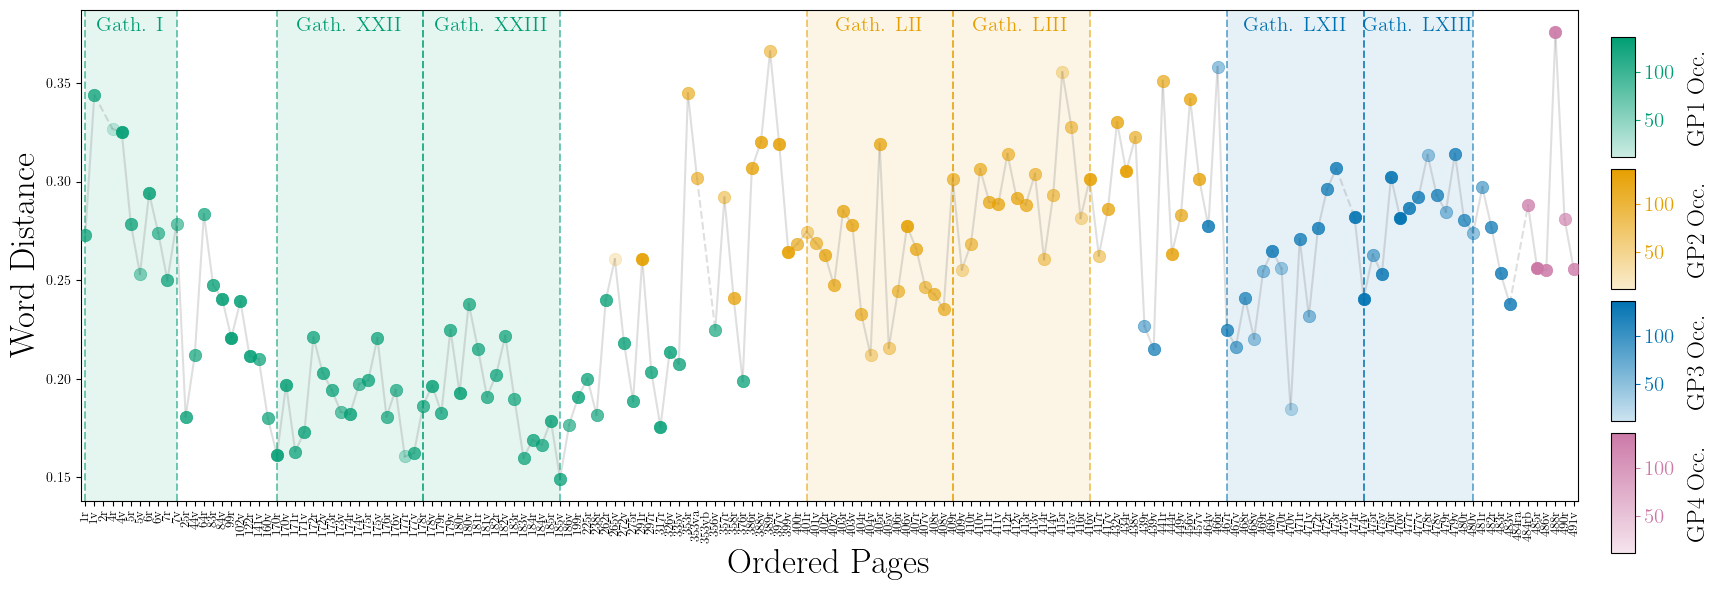

In [16]:
# Word separation
plot_linear(df, y_metric="mean_w_distance_normalized_m",
            config=config, idx=idx)

## Crossed plots

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/notebooks/metrological_analyses/metrics_viz.py:1166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: cross_mean_ar_n_vs_mean_ar_a_recto_verso.jpeg


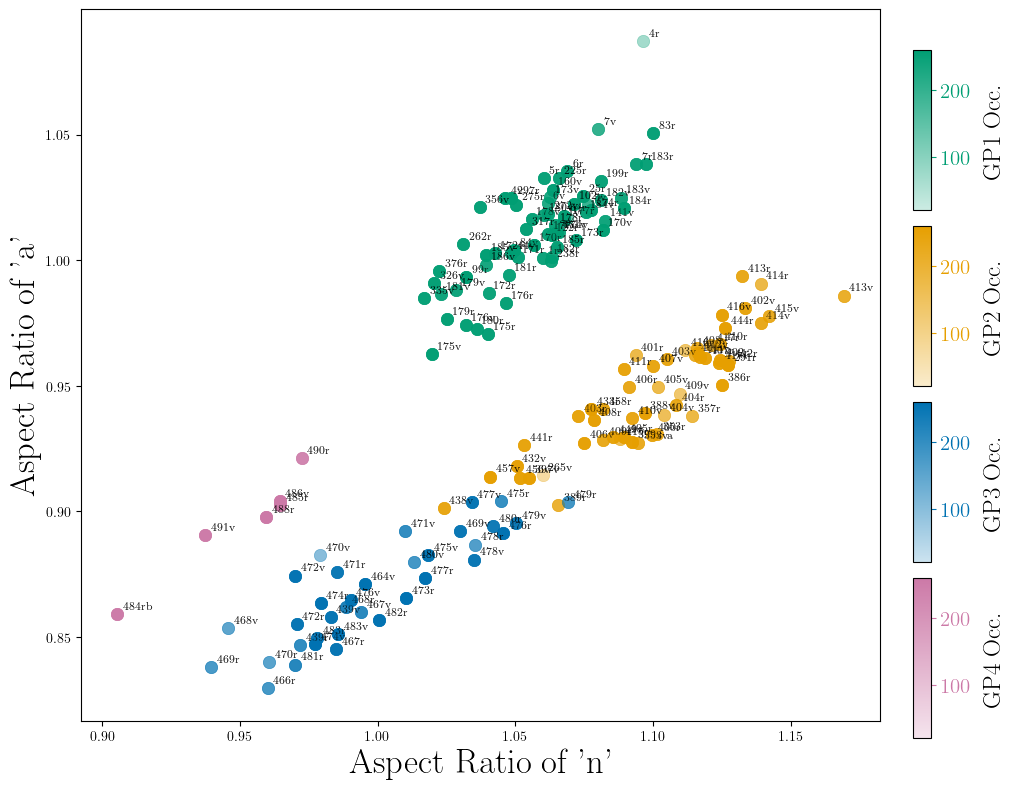

In [17]:
# ── CROSS PLOTS ───────────────────────────────────────────────────────────────

# AR of n vs AR of a
plot_cross(df, x_metric="mean_ar_n", y_metric="mean_ar_a", config=config)

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/notebooks/metrological_analyses/metrics_viz.py:1166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: cross_mean_ar_t_vs_cv_ar_t_recto_verso.jpeg


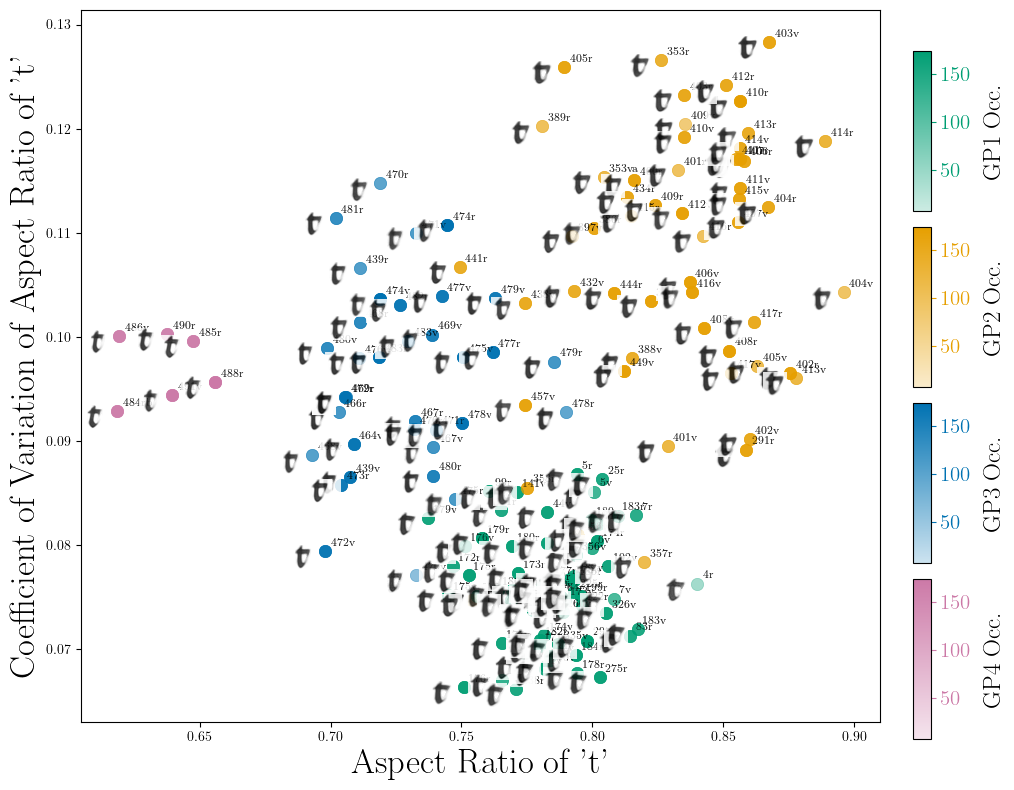

In [18]:
# AR of t vs CV of t — with prototype overlay
plot_cross(df, x_metric="mean_ar_t", y_metric="cv_ar_t", config=config,
           overlay_prototypes=True, proto_char="t",character_sprite_map=character_sprite_map)

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/notebooks/metrological_analyses/metrics_viz.py:1166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: cross_mean_b_distance_m_en_vs_mean_b_ar_en_recto_verso.jpeg


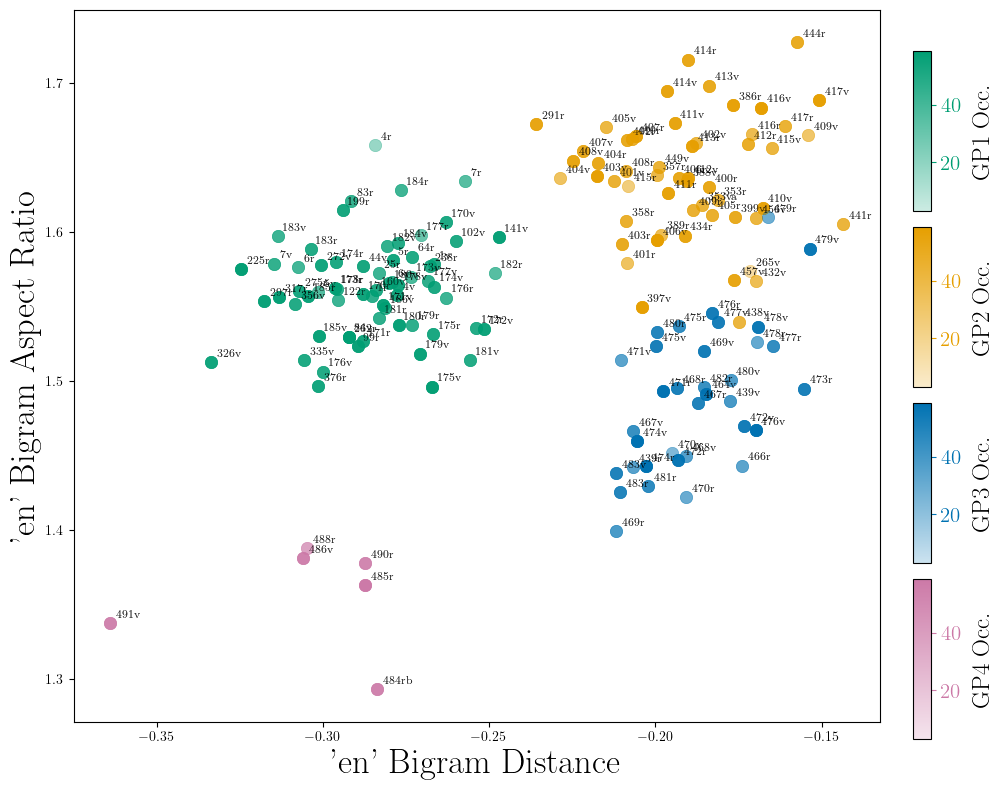

In [19]:
# Edge-to-edge distance of "en" vs AR of "en"
plot_cross(df, x_metric="mean_b_distance_m_en", y_metric="mean_b_ar_en", config=config)

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/notebooks/metrological_analyses/metrics_viz.py:1166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: cross_mean_b_distance_m_de_vs_cv_b_distance_de_recto_verso.jpeg


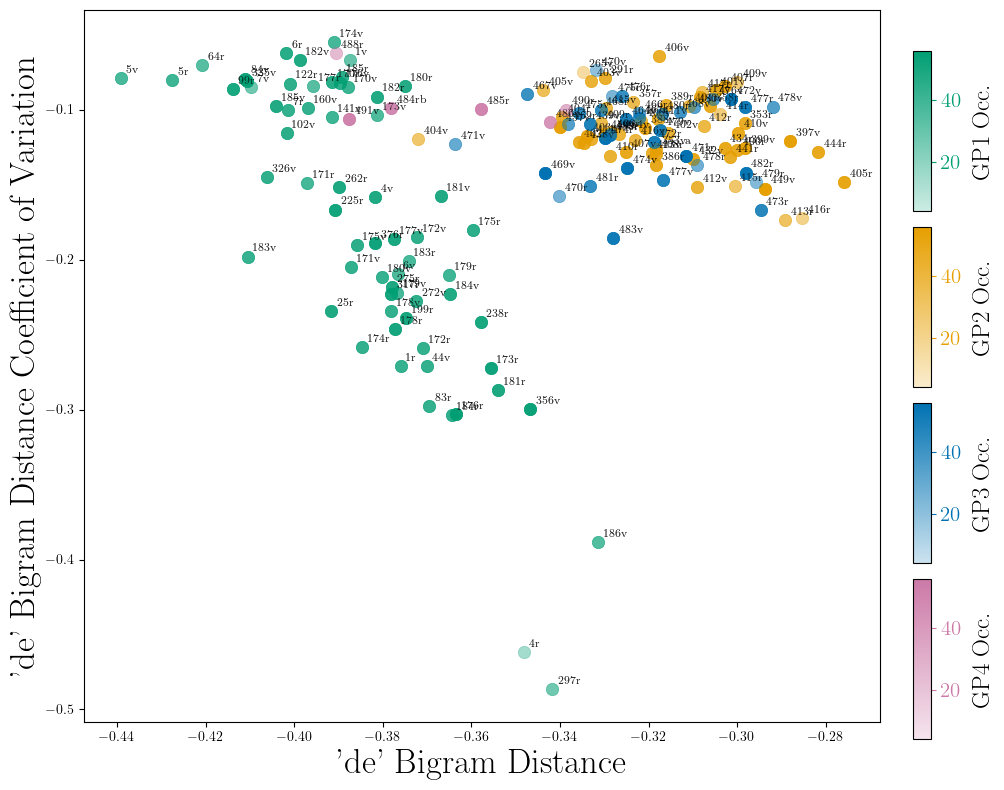

In [20]:
# Edge-to-edge distance of "de" vs CV of distance of "de"
plot_cross(df, x_metric="mean_b_distance_m_de", y_metric="cv_b_distance_de", config=config)